# Iterative debiasing at a single layer

Repeatedly applies debiasing at **one chosen layer**: at each iteration, trains a new CAV on the
current (already projected) activations, then projects again.

```
X₀ (raw at layer L)
  → train CAV₁ on X₀ → project → X₁
  → train CAV₂ on X₁ → project → X₂
  → ...
  → X_N
```

**Methods:** `lr` and `pclarc` only.  
After one orthogonal projection, diff_means gives a zero difference vector — re-training is undefined.

After N iterations the final activations are propagated through the remaining layers to obtain
the model output (768-dim CLIP image embedding).

Output structure:
```
data/activations/debiased/iterative/{CONCEPT}/{method}/layer_{LAYER}/
  train/
    iter_00.parquet   # raw (X₀), for reference
    iter_01.parquet   # after 1st projection
    ...
    iter_NN.parquet
    model_output.parquet   # 768-dim output after N iterations propagated through network
  test/  (same)
  cavs.csv           # CAV vector + train/test accuracy per iteration
  info.json
```

In [1]:
import json
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from dotenv import load_dotenv
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from transformers import AutoModel, AutoImageProcessor
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
load_dotenv()

ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from software.torch_lr import TorchLR

In [2]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
CONCEPT       = 'eyeglasses'
DEBIAS_LAYER  = 12       # which layer to iterate on
N_ITERATIONS  = 5        # number of train-project cycles
METHODS       = ['lr', 'pclarc']   # diff_means excluded — undefined after 1st projection
GPU_BATCH_SIZE = 64
NUM_WORKERS    = 4
MODEL_ID       = 'openai/clip-vit-large-patch14'
PARQUET_COMPRESSION = 'snappy'
NUM_LAYERS     = 24

SOLVER   = 'torch_lr'
SOLVER_C = 0.1

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
IMAGES_DIR    = ROOT / 'data' / 'images'
RAW_DIR       = ROOT / 'data' / 'activations' / 'raw'
DATA_OUT      = ROOT / 'data' / 'activations' / 'debiased' / 'iterative' / CONCEPT

assert METADATA_PATH.exists(), f'Missing: {METADATA_PATH}'
assert RAW_DIR.exists(),       f'Run 02_get_activations.ipynb first'

df_meta  = pd.read_csv(METADATA_PATH)
df_train = df_meta[df_meta['split'] == 'train'][['filename', CONCEPT]].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'test'][['filename',  CONCEPT]].reset_index(drop=True)

print(f'Concept      : {CONCEPT}')
print(f'Debias layer : {DEBIAS_LAYER}')
print(f'N iterations : {N_ITERATIONS}')
print(f'Methods      : {METHODS}')

Concept      : eyeglasses
Debias layer : 12
N iterations : 5
Methods      : ['lr', 'pclarc']


In [4]:
HF_TOKEN = os.getenv('HF_TOKEN')
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype    = torch.bfloat16 if device == 'cuda' else torch.float32

processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(
    MODEL_ID, torch_dtype=dtype, low_cpu_mem_usage=True, token=HF_TOKEN,
).to(device).eval()
print(f'Model: {MODEL_ID} | {device} | {dtype}')


class CelebADataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['filename']).convert('RGB')
        px  = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        return px, row['filename'], int(row[CONCEPT])


def make_loader(df):
    return DataLoader(
        CelebADataset(df, IMAGES_DIR, processor),
        batch_size=GPU_BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )


loader_train = make_loader(df_train)
loader_test  = make_loader(df_test)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model: openai/clip-vit-large-patch14 | cuda | torch.bfloat16


In [5]:
def make_cav_clf():
    if SOLVER == 'torch_lr':
        return TorchLR(C=SOLVER_C, max_iter=500, random_state=42)
    return SGDClassifier(
        loss='log_loss', penalty='l2', alpha=1.0 / (2.0 * SOLVER_C),
        max_iter=1000, tol=1e-4, random_state=42,
    )


def load_raw(split_label):
    split_df = df_train if split_label == 'train' else df_test
    df_raw = pd.read_parquet(RAW_DIR / split_label / f'layer_{DEBIAS_LAYER:02d}.parquet')
    df_raw = df_raw.merge(split_df, on='filename', how='left')
    feat_cols = [c for c in df_raw.columns if c not in ('filename', CONCEPT)]
    return df_raw[feat_cols].values.astype(np.float32), df_raw['filename'].tolist(), df_raw[CONCEPT].values.astype(int)


def train_cav(X, y, method):
    """Train CAV on current activations. Returns (cav, meta).

    meta keys:
        acc          — train accuracy
        threshold    — decision threshold for projection-based prediction:
                       LR     → -lr_intercept (so proj > threshold ↔ z > 0)
                       pclarc → midpoint between class means of projection
        target_val   — translation target for pclarc hook (mean projection of
                       the negative class). For LR this is None — LR uses its
                       own decision threshold and not a translation target.
        lr_intercept — LR intercept normalized by ||w|| (LR only); None otherwise
        clf          — fitted classifier object (LR only); None otherwise
    """
    if method == 'lr':
        clf = make_cav_clf()
        clf.fit(X, y)
        w = clf.coef_[0].astype(np.float64)
        norm = np.linalg.norm(w)
        if norm < 1e-10:
            return None, None   # degenerate — concept fully removed
        cav = (w / norm).astype(np.float32)
        # Normalise intercept so threshold lives in cav-projection space.
        b = float(clf.intercept_[0]) if hasattr(clf, 'intercept_') else 0.0
        lr_intercept = b / norm
        threshold = -lr_intercept
        return cav, {
            'acc':          clf.score(X, y),
            'threshold':    threshold,
            'target_val':   None,
            'lr_intercept': lr_intercept,
            'clf':          clf,
        }

    # pclarc — uses diff_means direction but shifts toward neg-class projection
    X64 = X.astype(np.float64)
    diff = X64[y == 1].mean(0) - X64[y == 0].mean(0)
    norm = np.linalg.norm(diff)
    if norm < 1e-10:
        return None, None
    cav = (diff / norm).astype(np.float32)
    proj = X64 @ cav.astype(np.float64)
    threshold  = float((proj[y == 1].mean() + proj[y == 0].mean()) / 2)
    target_val = float(proj[y == 0].mean())
    acc = accuracy_score(y, (proj > threshold).astype(int))
    return cav, {
        'acc':          acc,
        'threshold':    threshold,
        'target_val':   target_val,
        'lr_intercept': None,
        'clf':          None,
    }


def project(X, cav, method, target_val=None):
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    if method == 'pclarc':
        return (X64 + np.outer(target_val - X64 @ c64, c64)).astype(np.float32)
    return (X64 - np.outer(X64 @ c64, c64)).astype(np.float32)


def save_parquet(X, filenames, path):
    df = pd.DataFrame(X.astype(np.float16))
    df.columns = df.columns.astype(str)
    df.insert(0, 'filename', filenames)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, compression=PARQUET_COMPRESSION, index=False)


def run_propagate_and_capture(loader, X_injected, filenames_order, cav_np, method, target_val):
    """Inject X_injected at DEBIAS_LAYER output, propagate, capture model output.
    Returns (outputs_768, filenames).
    """
    fn_to_row = {fn: i for i, fn in enumerate(filenames_order)}
    X_t = torch.from_numpy(X_injected).to(device=device, dtype=dtype)

    encoder_layers = model.vision_model.encoder.layers
    outputs_buf, fn_all = [], []
    handles = []

    # Replace layer DEBIAS_LAYER output with X_injected rows (batch-aligned via filename)
    batch_idx_buf = [0]

    def inject_hook(module, input, output):
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output
        bs       = hidden.shape[0]
        start    = batch_idx_buf[0]
        rows     = X_t[start:start + bs]          # already-projected activations
        h_new    = hidden.clone()
        h_new[:, 0, :] = rows.to(hidden.dtype)
        batch_idx_buf[0] += bs
        return (h_new,) + output[1:] if is_tuple else h_new

    handles.append(encoder_layers[DEBIAS_LAYER].register_forward_hook(inject_hook))

    def capture_output(module, input, output):
        outputs_buf.append(output.detach().float().cpu().numpy())

    handles.append(model.visual_projection.register_forward_hook(capture_output))

    try:
        with torch.no_grad():
            for pixels, fnames, _ in loader:
                model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                fn_all.extend(fnames)
    finally:
        for h in handles:
            h.remove()

    return np.concatenate(outputs_buf, axis=0), fn_all

In [6]:
for method in METHODS:
    out_base = DATA_OUT / method / f'layer_{DEBIAS_LAYER:02d}'
    if (out_base / 'cavs.csv').exists():
        print(f'[{method}] Already exists — skipping.')
        continue

    print(f'\n=== Method: {method} ===')
    cav_records = []

    # Load raw activations at DEBIAS_LAYER
    X_tr, fn_tr, y_tr = load_raw('train')
    X_te, fn_te, y_te = load_raw('test')

    # Save iter_00 = raw (reference)
    save_parquet(X_tr, fn_tr, out_base / 'train' / 'iter_00.parquet')
    save_parquet(X_te, fn_te, out_base / 'test'  / 'iter_00.parquet')

    X_cur_tr, X_cur_te = X_tr.copy(), X_te.copy()
    final_cav = None
    final_meta = None

    for it in tqdm(range(1, N_ITERATIONS + 1), desc=method):
        cav, meta = train_cav(X_cur_tr, y_tr, method)
        if cav is None:
            print(f'  Iteration {it}: concept fully removed, stopping.')
            break

        # #1, #2 — test accuracy uses a true decision threshold:
        #   LR     → use the trained classifier directly (clf.predict),
        #            equivalent to (proj + lr_intercept > 0) i.e. proj > threshold.
        #   pclarc → threshold = midpoint between class projection means
        #            (NOT target_val, which is the translation target only).
        if method == 'lr':
            acc_te_proj = float(meta['clf'].score(X_cur_te, y_te))
        else:
            proj_te = X_cur_te.astype(np.float64) @ cav.astype(np.float64)
            acc_te_proj = accuracy_score(
                y_te, (proj_te > meta['threshold']).astype(int),
            )

        X_cur_tr = project(X_cur_tr, cav, method, meta['target_val'])
        X_cur_te = project(X_cur_te, cav, method, meta['target_val'])

        save_parquet(X_cur_tr, fn_tr, out_base / 'train' / f'iter_{it:02d}.parquet')
        save_parquet(X_cur_te, fn_te, out_base / 'test'  / f'iter_{it:02d}.parquet')

        cav_records.append({
            'iteration':    it,
            'train_acc':    meta['acc'],
            'test_acc':     acc_te_proj,
            'threshold':    meta['threshold'],
            'target_val':   meta['target_val'],
            'lr_intercept': meta['lr_intercept'],
            **{f'cav_{i}': float(cav[i]) for i in range(len(cav))},
        })
        final_cav, final_meta = cav, meta

    # Propagate final activations through remaining layers → model output
    print(f'  Propagating final activations through network...')
    tv = final_meta['target_val'] if final_meta else None
    outputs_tr, fn_tr2 = run_propagate_and_capture(loader_train, X_cur_tr, fn_tr, final_cav, method, tv)
    outputs_te, fn_te2 = run_propagate_and_capture(loader_test,  X_cur_te, fn_te, final_cav, method, tv)

    save_parquet(outputs_tr, fn_tr2, out_base / 'train' / 'model_output.parquet')
    save_parquet(outputs_te, fn_te2, out_base / 'test'  / 'model_output.parquet')

    pd.DataFrame(cav_records).to_csv(out_base / 'cavs.csv', index=False)

    info = {
        'concept':       CONCEPT,
        'method':        method,
        'debias_type':   'iterative_single_layer',
        'debias_layer':  DEBIAS_LAYER,
        'n_iterations':  N_ITERATIONS,
        'model_id':      MODEL_ID,
        'created_at':    datetime.now(timezone.utc).isoformat(),
        'description': (
            f"Iterative debiasing of '{CONCEPT}' at layer {DEBIAS_LAYER} using {method}. "
            f"Each iteration trains a new CAV on the current projected activations and projects again. "
            f"iter_00 = raw reference; iter_NN = after N projections. "
            f"model_output = 768-dim CLIP embedding after propagating iter_{N_ITERATIONS:02d} through the network."
        ),
    }
    with open(out_base / 'info.json', 'w') as f:
        json.dump(info, f, indent=2)

    print(f'  Done: {method}')

print('\nDone.')


=== Method: lr ===


lr:   0%|          | 0/5 [00:00<?, ?it/s]

  Propagating final activations through network...


  Done: lr

=== Method: pclarc ===


pclarc:   0%|          | 0/5 [00:00<?, ?it/s]

  Propagating final activations through network...


  Done: pclarc

Done.


In [7]:
# ## Visualization: CAV accuracy per iteration

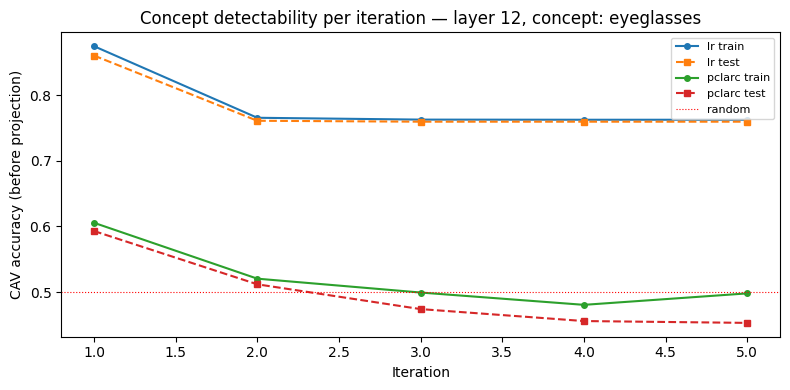

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for method in METHODS:
    p = DATA_OUT / method / f'layer_{DEBIAS_LAYER:02d}' / 'cavs.csv'
    if not p.exists():
        continue
    df = pd.read_csv(p)
    ax.plot(df['iteration'], df['train_acc'], marker='o', ms=4, label=f'{method} train')
    ax.plot(df['iteration'], df['test_acc'],  marker='s', ms=4, ls='--', label=f'{method} test')

ax.axhline(0.5, color='red', lw=0.8, ls=':', label='random')
ax.set_xlabel('Iteration')
ax.set_ylabel('CAV accuracy (before projection)')
ax.set_title(f'Concept detectability per iteration — layer {DEBIAS_LAYER}, concept: {CONCEPT}')
ax.legend(fontsize=8)
plt.tight_layout()

PLOT_DIR = ROOT / 'notebooks' / 'results' / 'multiple_debias' / CONCEPT / 'iterative'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_DIR / f'cav_acc_iterative_layer{DEBIAS_LAYER}.png', dpi=150)
plt.show()